# Tier 5 · Notebook 26 — Normalizing Flows

> **Goal:** the third major generative paradigm — **normalizing flows** — which give **exact likelihoods** (unlike the VAE's lower bound, the GAN's none, or diffusion's approximation) by building the model out of **invertible transformations** and the change-of-variables formula. We implement a **RealNVP** flow from scratch on 2-D data and see it learn a density we can both *sample* from and *exactly evaluate*.

**The idea.** Suppose you have a simple base distribution — a Gaussian $z\sim\mathcal{N}(0,I)$ — and an **invertible, differentiable** function $f$ that maps data $x$ to $z$: $z=f(x)$. Then the change-of-variables formula gives the *exact* density of $x$:
$$\log p(x) = \log p_Z(f(x)) + \log\left|\det \frac{\partial f}{\partial x}\right|.$$
So if we make $f$ a flexible neural network that's **invertible** and whose **Jacobian determinant is easy to compute**, we can (a) evaluate $\log p(x)$ exactly (train by maximizing it), and (b) generate by sampling $z\sim\mathcal{N}(0,I)$ and applying $x=f^{-1}(z)$. The whole challenge is designing invertible layers with tractable Jacobians — which is exactly what **coupling layers** solve.


## 0. The coupling layer (RealNVP)

The trick (Dinh et al.): split the input into two halves $x_1, x_2$ and transform only *one* half, conditioned on the other:
$$y_1 = x_1, \qquad y_2 = x_2 \odot \exp(s(x_1)) + t(x_1),$$
where $s,t$ are arbitrary neural nets (they don't need to be invertible!). This is:
- **Invertible**: $x_2 = (y_2 - t(x_1))\odot\exp(-s(x_1))$, and $x_1=y_1$. Easy to reverse.
- **Cheap Jacobian**: since $y_1$ doesn't change and $y_2$ depends on $x_2$ only through a scaling, the Jacobian is **triangular**, so its determinant is just the product of the diagonal: $\log|\det J| = \sum s(x_1)$. No expensive determinant.

We **alternate** which half gets transformed across layers (so every dimension eventually gets updated), and stack several. Let's build it.


In [1]:
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

class Coupling(nn.Module):
    def __init__(s, mask, dim=2, hidden=128):
        super().__init__(); s.register_buffer("mask", mask)     # 1 = keep, 0 = transform
        s.st = nn.Sequential(nn.Linear(dim,hidden), nn.ReLU(), nn.Linear(hidden,hidden), nn.ReLU(),
                             nn.Linear(hidden, 2*dim))            # outputs s and t
    def forward(s, x):                                           # x -> y, and log|det|
        xm = x*s.mask
        st = s.st(xm); shift, scale = st.chunk(2,-1)
        scale = torch.tanh(scale) * (1-s.mask)                   # only transform the non-masked half
        shift = shift * (1-s.mask)
        y = xm + (1-s.mask)*(x*torch.exp(scale) + shift)
        return y, scale.sum(-1)                                  # log|det J| = sum of scales
    def inverse(s, y):                                           # y -> x
        ym = y*s.mask
        st = s.st(ym); shift, scale = st.chunk(2,-1)
        scale = torch.tanh(scale)*(1-s.mask); shift = shift*(1-s.mask)
        x = ym + (1-s.mask)*((y - shift)*torch.exp(-scale))
        return x

class RealNVP(nn.Module):
    def __init__(s, n_layers=6, dim=2):
        super().__init__()
        masks = [torch.tensor([1.,0.] if i%2==0 else [0.,1.]) for i in range(n_layers)]
        s.layers = nn.ModuleList([Coupling(m) for m in masks])
    def forward(s, x):                    # data -> latent z, accumulate log|det|
        logdet = 0
        for l in s.layers:
            x, ld = l(x); logdet = logdet + ld
        return x, logdet
    def inverse(s, z):                    # latent z -> data x (for sampling)
        for l in reversed(s.layers): z = l.inverse(z)
        return z
    def log_prob(s, x):                   # EXACT log-likelihood via change of variables
        z, logdet = s(x)
        log_pz = -0.5*(z**2).sum(-1) - np.log(2*np.pi)          # standard normal
        return log_pz + logdet

flow = RealNVP().to(device)
# sanity: the transform is invertible
x = torch.randn(5,2,device=device)
z,_ = flow(x); x_rec = flow.inverse(z)
print("invertibility check, max abs err:", (x-x_rec).abs().max().item())
assert (x-x_rec).abs().max() < 1e-5
print("✅ coupling layers are exactly invertible (data → z → data recovers the input)")


invertibility check, max abs err: 8.940696716308594e-08
✅ coupling layers are exactly invertible (data → z → data recovers the input)


## 1. Train by maximizing exact likelihood

Unlike every other generative model so far, we can compute $\log p(x)$ **exactly** and just maximize it (minimize negative log-likelihood). No bound, no adversary, no denoising. Target: the two-moons distribution.


In [2]:
def two_moons(n):
    t = np.linspace(0, np.pi, n//2)
    a = np.stack([np.cos(t), np.sin(t)],1); b = np.stack([1-np.cos(t), 0.5-np.sin(t)],1)
    X = np.concatenate([a,b]) + np.random.randn(n,2)*0.05
    return torch.tensor((X-X.mean(0))/X.std(0), dtype=torch.float32)
data = two_moons(3000).to(device)

flow = RealNVP().to(device); opt = torch.optim.Adam(flow.parameters(), 1e-3)
losses=[]
for step in range(3000):
    x = data[torch.randint(0,len(data),(256,),device=device)]
    loss = -flow.log_prob(x).mean()                             # negative exact log-likelihood
    opt.zero_grad(); loss.backward(); opt.step(); losses.append(loss.item())
    if step%1000==0 or step==2999: print(f"step {step:4d}  NLL {loss.item():.3f}")
print("✅ flow trained by exact maximum likelihood")


step    0  NLL 2.984


step 1000  NLL 1.297


step 2000  NLL 1.231


step 2999  NLL 1.139
✅ flow trained by exact maximum likelihood


## 2. What the flow learned — density, samples, and the mapping

Three views that only a flow can give you all of:
1. **Exact density** $p(x)$ evaluated on a grid (a heatmap — impossible for a GAN, only a bound for a VAE).
2. **Samples** drawn via $x=f^{-1}(z)$, $z\sim\mathcal{N}(0,I)$.
3. **The learned map** $f$: data pushed to latent space should become a clean **Gaussian** (that's what training enforced).


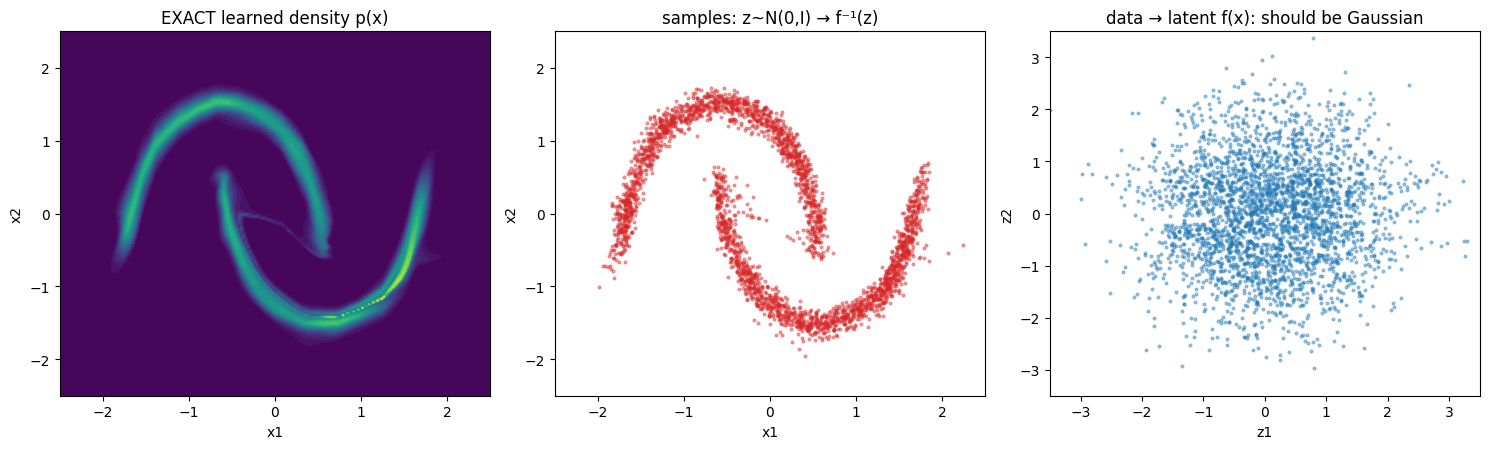

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
# (1) exact density heatmap
gx = np.linspace(-2.5,2.5,200); X1,X2 = np.meshgrid(gx,gx)
grid = torch.tensor(np.stack([X1.ravel(),X2.ravel()],1), dtype=torch.float32, device=device)
with torch.no_grad(): logp = flow.log_prob(grid).cpu().numpy().reshape(200,200)
ax[0].contourf(X1, X2, np.exp(logp), levels=30, cmap="viridis")
ax[0].set_title("EXACT learned density p(x)"); ax[0].set_xlabel("x1"); ax[0].set_ylabel("x2")
# (2) samples from the flow
with torch.no_grad(): samp = flow.inverse(torch.randn(3000,2,device=device)).cpu().numpy()
ax[1].scatter(samp[:,0], samp[:,1], s=4, alpha=0.4, color="tab:red")
ax[1].set_title("samples: z~N(0,I) → f⁻¹(z)"); ax[1].set_xlabel("x1"); ax[1].set_ylabel("x2"); ax[1].set_xlim(-2.5,2.5); ax[1].set_ylim(-2.5,2.5)
# (3) data pushed to latent space (should be ~Gaussian)
with torch.no_grad(): z,_ = flow(data); z = z.cpu().numpy()
ax[2].scatter(z[:,0], z[:,1], s=4, alpha=0.4, color="tab:blue")
ax[2].set_title("data → latent f(x): should be Gaussian"); ax[2].set_xlabel("z1"); ax[2].set_ylabel("z2"); ax[2].set_xlim(-3.5,3.5); ax[2].set_ylim(-3.5,3.5)
plt.tight_layout(); plt.show()


**What to notice.** Three things a flow uniquely delivers together: **(1)** an *exact* density heatmap that traces the two crescents — you can query $p(x)$ at any point (great for anomaly detection, exact likelihood comparison); **(2)** clean **samples** that reproduce the moons; **(3)** the data mapped into latent space forms a **round Gaussian blob** — training pushed the complicated data distribution into the simple base distribution, and because $f$ is invertible, running it backward turns Gaussian noise into moons. The invertibility (verified in §0) is what ties evaluation and generation into one consistent model.

## 3. The generative-model landscape (Tier 5 recap)
You've now built all four major families. Their tradeoffs:

| Model | Likelihood | Sample quality | Training | Sampling speed |
|---|---|---|---|---|
| **VAE** (NB23) | lower bound (ELBO) | blurry | stable | fast |
| **GAN** (NB24) | none | sharp | unstable (collapse) | fast |
| **Diffusion** (NB25) | approximate | sharp, diverse | stable (MSE) | slow (many steps) |
| **Normalizing flow** (NB26) | **exact** | good | stable | fast |

Flows trade architectural freedom (must be invertible with tractable Jacobian) for *exact likelihoods* and fast, exact inversion. They shine where you need the actual probability (density estimation, anomaly detection, variational inference) — and the invertible-layer idea reappears in flow-matching and continuous normalizing flows, which connect flows to diffusion.

## 4. What you built / learned
- The **change-of-variables** formula for exact likelihood via invertible maps.
- **RealNVP coupling layers**: invertible, with a triangular Jacobian (determinant = product of diagonal ⇒ cheap).
- Trained a flow by **exact maximum likelihood** (no bound/adversary/denoising).
- Visualized the **exact density**, samples, and the data→Gaussian mapping.
- The four-way comparison of generative model families.

## 5. Exercises
1. **More expressive.** Add more coupling layers and a random permutation/1×1 conv between them (Glow). Does the density fit improve?
2. **Anomaly detection.** Use the exact $\log p(x)$ to flag out-of-distribution points; test on data from a different distribution.
3. **Higher dim.** Fit a flow to a small image dataset (e.g., 8×8 digits); how does cost scale?
4. **Autoregressive flow.** Implement a MADE/IAF-style autoregressive flow; compare expressivity vs coupling flows.
5. **Continuous flows.** Read about Neural ODEs / FFJORD — flows with a continuous-depth transform.
6. **Flow matching.** How do flow matching / rectified flows connect normalizing flows to diffusion?

## 6. Interview / residency framing
- *"How do normalizing flows work?"* → invertible map from data to a simple base distribution; exact log-likelihood via change of variables (log p(x) = log p_z(f(x)) + log|det J|).
- *"Why coupling layers?"* → they're invertible with a triangular Jacobian, so the determinant is the product of the diagonal — cheap, unlike a general Jacobian.
- *"Flow vs VAE vs GAN vs diffusion?"* → flow gives *exact* likelihood + exact fast inversion but is architecturally constrained; VAE bound + blurry; GAN no likelihood + sharp/unstable; diffusion approximate + sharp/slow.
- *"When would you use a flow?"* → when you need the actual density (anomaly/OOD detection, exact likelihood, variational posteriors).
- *"What's the constraint that makes flows hard?"* → every layer must be invertible with a tractable Jacobian determinant, limiting architecture choices.

## 📚 References & papers

This notebook reproduces / builds on:

- **Density estimation using Real NVP** — Dinh, Sohl-Dickstein & Bengio (2016), arXiv:1605.08803. The coupling-layer flow this notebook implements.
- **NICE: Non-linear Independent Components Estimation** — Dinh, Krueger & Bengio (2014), arXiv:1410.8516. The original coupling idea.
- **Variational Inference with Normalizing Flows** — Rezende & Mohamed (2015), arXiv:1505.05770. Coined "normalizing flows".
- **Glow: Generative Flow with Invertible 1×1 Convolutions** — Kingma & Dhariwal (2018), arXiv:1807.03039.

---
**Next (Tier 6):** *Notebook 27 — Paper reproduction workflow + Grokking*: the methodology for reproducing a paper end-to-end, worked through a full reproduction of the striking "grokking" phenomenon.
